In [5]:
#datasets
full_path = "C://Users//rayan//Desktop//ProjetML//Dataset//bank-full.csv"
partial_path = "C://Users//rayan//Desktop//ProjetML//Dataset//bank.csv"

In [ ]:
import pandas as pd

df = pd.read_csv(full_path, sep=';')

X = df.drop('y', axis=1)   # Features
y = df['y']                # Target

# bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")



# Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

In [27]:
#dimensions:
print("dimensions : ", df.shape)

print("--------------------------------------------------------------------------------------------------------------")
#infos
df.info()

dimensions :  (45211, 17)
--------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64

In [28]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [34]:
#distribution des y
print("Distribution des", df['y'].value_counts())
print("Distribution en % des",df['y'].value_counts(normalize=True) * 100)

Distribution des y
no     39922
yes     5289
Name: count, dtype: int64
Distribution en % des y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [35]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [37]:
for col in X.columns:
    print(col, X[col].value_counts().head())

age age
32    2085
31    1996
33    1972
34    1930
35    1894
Name: count, dtype: int64
job job
blue-collar    9732
management     9458
technician     7597
admin.         5171
services       4154
Name: count, dtype: int64
marital marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default default
no     44396
yes      815
Name: count, dtype: int64
balance balance
0    3514
1     195
2     156
4     139
3     134
Name: count, dtype: int64
housing housing
yes    25130
no     20081
Name: count, dtype: int64
loan loan
no     37967
yes     7244
Name: count, dtype: int64
contact contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
day day
20    2752
18    2308
21    2026
17    1939
6     1932
Name: count, dtype: int64
month month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
Name

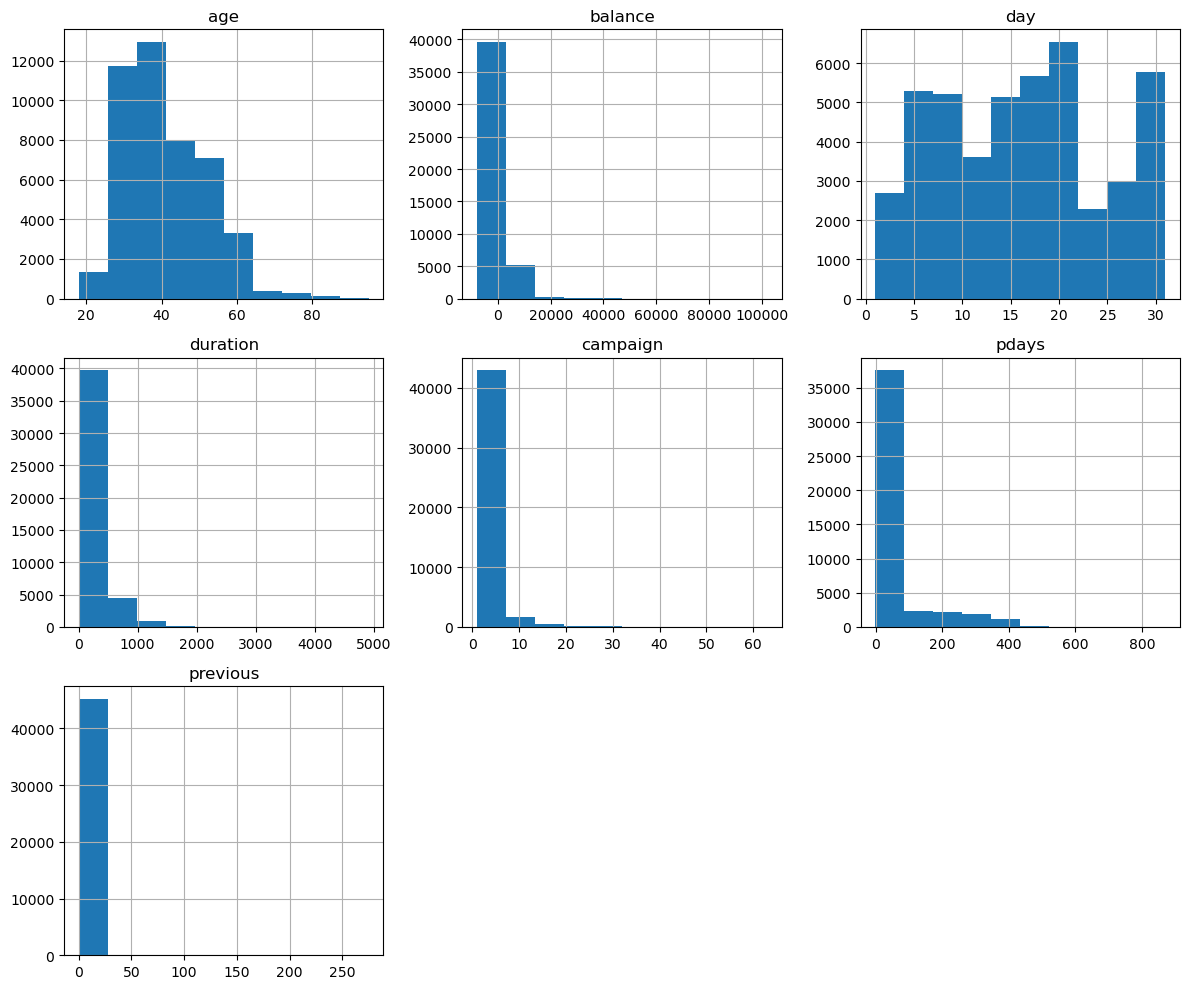

In [39]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

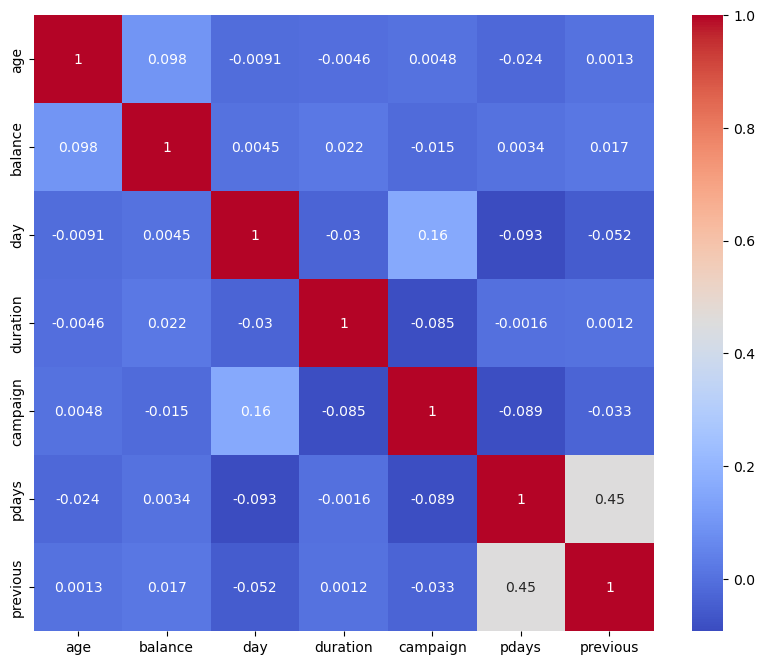

In [40]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()